# Ejercicio de Feedback Regresiones y Random Forest

## Regresión lineal

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan, het_white
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# --------------------------------------------------------------------------------------
# Agregando librerias necesarias para la construccion del modelo de Regresión Lineal.
# --------------------------------------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# --------------------------------------------------------------------------------------
# Agregando librerias necesarias para la construccion del modelo de Regresión Logística.
# --------------------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.metrics import roc_curve, auc, roc_auc_score
# --------------------------------------------------------------------------------------
# Agregando librerias para construcción de modelos Árbol de decisión y Random Forest.
# --------------------------------------------------------------------------------------
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
# -----------------------------------------------------------------------------------

In [34]:
# Creando dataframes e importando los datos correspondientes.
df_precio_casas = pd.read_csv('precio_casas.csv')
df_deteccion_cancer = pd.read_csv('deteccion_cancer.csv')

**Apartado 1.1**

In [35]:
# Calcular la media y la varianza de la variables size del dataset.
media_size = df_precio_casas['size'].mean()
varianza_size = df_precio_casas['size'].var()
print(f"La media de la variable size es: {media_size:.2f}")
print(f"La varianza de la variable size es: {varianza_size:.2f}")

La media de la variable size es: 97.28
La varianza de la variable size es: 1906.63


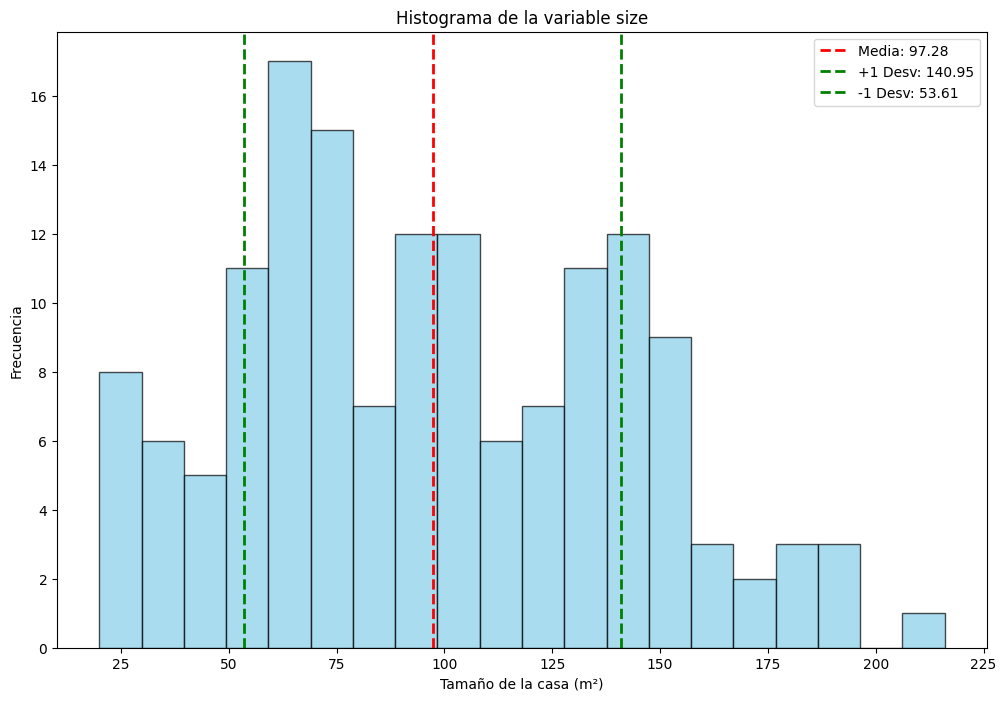

In [36]:
# Calculando la desviación estandar de la variable size.
desv_size = df_precio_casas['size'].std()

# Generando el histograma incluyendo la media y la desviación estandar.
# Dibujar histograma
plt.figure(figsize=(12, 8))
plt.hist(df_precio_casas['size'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Agregar la línea - media.
plt.axvline(media_size, color='red', linestyle='dashed', linewidth=2, label=f"Media: {media_size:.2f}")

# Agregar las líneas de desviación estándar

# Limite de desviación superior.
plt.axvline(media_size + desv_size, color='green', linestyle='dashed', linewidth=2,label=f"+1 Desv: {media_size+desv_size:.2f}")

# Limite de desviación inferior.
plt.axvline(media_size - desv_size, color='green', linestyle='dashed', linewidth=2, label=f"-1 Desv: {media_size-desv_size:.2f}")

# Agregando los textos al gráfico.
plt.title("Histograma de la variable size")
plt.xlabel("Tamaño de la casa (m²)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

**Interpretación del resultado**

La media del tamaño de las casas es aproximado de 100 metros cuadrados, sin embargo, la mayor parte de las casas en los datos proporcionados, tienen una variación en relación a la media de + o - 40 metros cuadrados, lo que nos dice que hay una inclinación de la oferta de casas medianas para el conjunto de datos. Por lo tanto, si tomamos en cuenta la variable size como un factor determinante para la asignación de precio, podríamos tener una idea que la relación valor-benficio, podria ser directamente proporcional y por lo tanto, lineal, ya que entre más grande una casa, podriamos determinar que va a tener un mayor precio.

***Apartado 1.2***

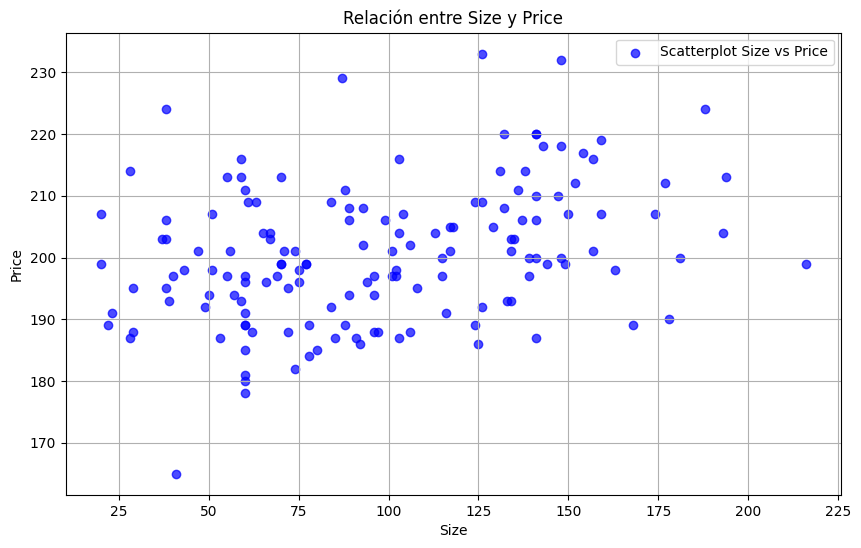

In [37]:
# Crear gráfico scatterplot de size vs price.
plt.figure(figsize=(10, 6))
plt.scatter(df_precio_casas['size'], df_precio_casas['price'], color='blue', alpha=0.7, marker='o', label='Scatterplot Size vs Price')
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Relación entre Size y Price')
plt.legend()
plt.grid(True)

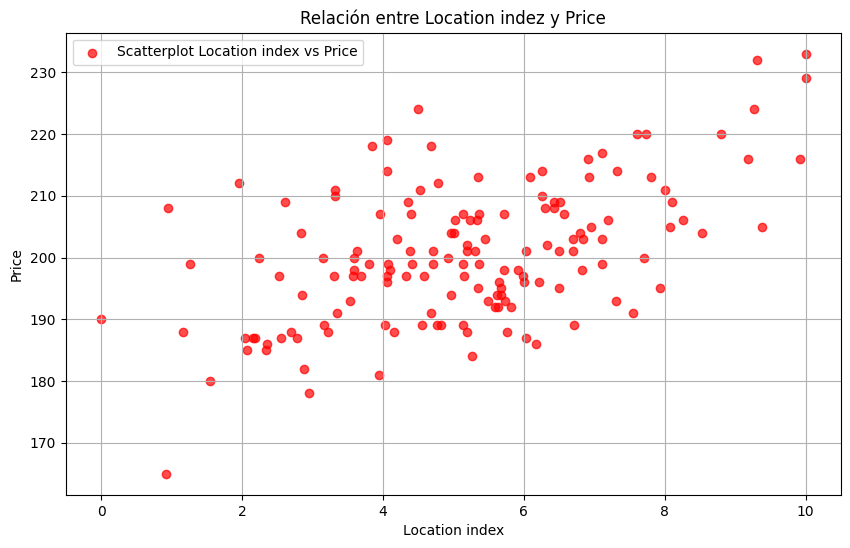

In [38]:
# Crear gráfico scatterplot de location_index vs price.
plt.figure(figsize=(10, 6))
plt.scatter(df_precio_casas['location_index'], df_precio_casas['price'], color='red', alpha=0.7, marker='o', label='Scatterplot Location index vs Price')
plt.xlabel('Location index')
plt.ylabel('Price')
plt.title('Relación entre Location indez y Price')
plt.legend()
plt.grid(True)

**Cual de las dos variables elegirías como variable predictora para el desarrollo del modelo, tomando como variable objetivo la variable price?**

Según los scatterplots graficados, A priori, identifico la variable location_indez como una buena variable predictora debido a que muestra una relación lineal más clara entre location_index y price. Aunque la gráfica de size vs price brinda un comportamiento similar, se identifica mayor dispersión de los datos, lo que puede conllevar al modelo a dar algunos resultados que no sean tan certeros, incluso en la etapa de entrenamiento del mismo. Siendo que el gráfico location_index vs price denota una mayor definición de relación lineal, me parece que puede ser el mas certero para el desarrollo y entrenamiento del modelo.

***Apartado 1.3***

In [39]:
# Desarrollar un modelo de Regresión lineal con la variable Location_index como predictora y Price como objetivo.

# Definiendo variable predictora.
var_predictora = df_precio_casas[['location_index']]
# Definiendo variable objetivo.
var_objetivo = df_precio_casas['price']

# Dividir en entrenamiento (80%) y prueba (20%) con semilla 135
X_train, X_test, Y_train, Y_test = train_test_split(var_predictora, var_objetivo, test_size=0.2, random_state=135)

# Crear y entrenar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, Y_train)

# Predicciones sobre el conjunto de prueba
Y_pred = modelo.predict(X_test)

# Evaluación del modelo
print("Coeficiente (pendiente):", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)
print("Error cuadrático medio (MSE):", mean_squared_error(Y_test, Y_pred))
print("R^2 en test:", r2_score(Y_test, Y_pred))

Coeficiente (pendiente): 3.151542099510651
Intercepto: 184.12655459709424
Error cuadrático medio (MSE): 99.32136384535715
R^2 en test: 0.20180350337246122


In [40]:
# Aplicando el Test Reset de Ramsey.

# Definiendo la constante del modelo.
X_const = sm.add_constant(var_predictora)

# Ajustar modelo de regresión lineal, aplicando el metodo OLS de Statsmodels.api
modelo = sm.OLS(var_objetivo, X_const).fit()

# Aplicar Test RESET de Ramsey
# Usamos la opción 'quadratic' o 'fitted' para probar especificación
reset_test = linear_reset(modelo, power=2, test_type="fitted")

print(reset_test)

<Wald test (chi2): statistic=3.754910964862165, p-value=0.052652599810975594, df_denom=1>


**Que ocurre con el Test Reset de Ramsey?**

Al tener un valor de p-value > 0.05, aparentemente no hay justificante que nos dicte una mala conformación del modelo. Sin embargo, el factor R^2 únicamente explica el 20% de variación del precio como resultado de utilizar la variable location_index como única predictora. Siendo que, por sentido común, el mercado inmobiliario puede depender de más variables predictoras clave, no es suficiente una Regresión Lineal, con solo una variable predictora para tener los valores de la variable objetivo con muy buena predicción en los precios de vivienda. Con esto queda claro que se deben usar más variables para predecir y construir un modelo confiable.

**Que consecuencias puede tener, en este caso, el resultado del Test Reset de Ramsey en nuestro modelo?**

Considero que una consecuencia positiva, dado que, nos confirma que el modelo está practicamente incompleto con una sola variable predictora, ya que, los resultados del Test Reset es una parte complementaria a los resultados de nuestro modelo de regresión lineal, donde el MSE calculado es alto y el R^2 es bastante bajo, lo cual nos brinda resultados contrarios a lo que buscamos en un modelo de Regresión Lineal confiable, donde los resultados de estos factores son muy contrarios a lo obtenido en nuestro modelo actual.

***Apartado 1.4***

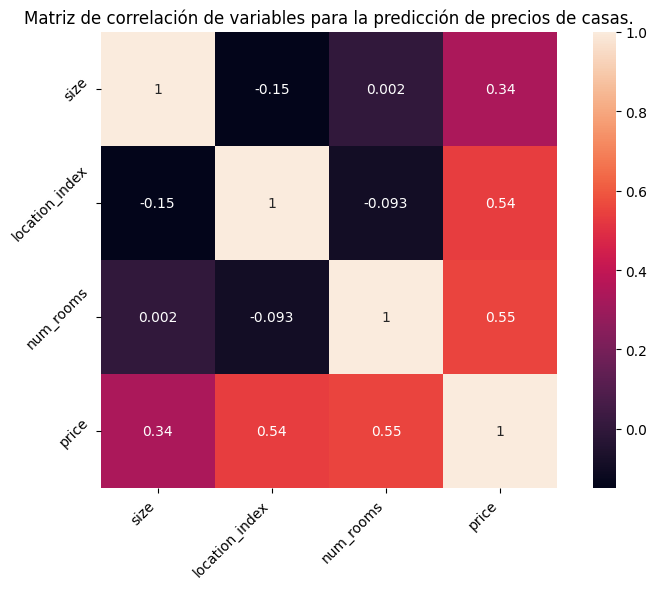

In [41]:
# Creando un modelo de regresión multiple.

# Generar correlation_matrix.
corr_matrix = df_precio_casas.corr()

# Visualizar correlación de variables, utilizando Correlation Heat Map.
plt.figure(figsize=(8, 6))
plt.title('Matriz de correlación de variables para la predicción de precios de casas.')
graph = sns.heatmap(corr_matrix, square = True, annot=True, linecolor = 'white')
graph.set_xticklabels(graph.get_xticklabels(), rotation=45, horizontalalignment='right')
graph.set_yticklabels(graph.get_yticklabels(), rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.show()

In [42]:
# Creando el modelo de Regresión Múltiple.

# Particionando los datos como 80% training y 20% testing, con seed = 135.
train, test = train_test_split(df_precio_casas, test_size=0.2, random_state=135)

# Asignando elementos predictores para train y test.
X_train = train[['size', 'location_index', 'num_rooms']]
X_test = test[['size', 'location_index', 'num_rooms']]

# Asignando elemento objetivo para train y test.
Y_train = train[['price']]
Y_test = test[['price']]

# Creando el modelo de regresión lineal múltiple.
modelo = LinearRegression()

# Entrenando el modelo de regresión múltiple.
modelo.fit(X_train, Y_train)

# Cálculo de predicciones sobre el conjunto de prueba.
Y_test['predicted_price'] = modelo.predict(X_test).round(0)

# Evaluación del modelo.
coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_
mse = mean_squared_error(Y_test['price'], Y_test['predicted_price'])
rcuadrado = r2_score(Y_test['price'], Y_test['predicted_price'])

# Imprimir resultados.
print("Coeficiente (pendiente):", coeficiente)
print("Intercepto:", intercepto)
print("Error cuadrático medio (MSE):", mse)
print("R^2 en test:", rcuadrado)



Coeficiente (pendiente): [ 0.10698583  3.67669354 13.37526554]
Intercepto: [130.54391678]
Error cuadrático medio (MSE): 12.333333333333334
R^2 en test: 0.9008831224495263


/tmp/ipython-input-3401207072.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_test['predicted_price'] = modelo.predict(X_test).round(0)


**Calcula R^2 del modelo. Crees que es un valor de calidad confiable?**

Con el resultado de r^2 = 0.90, se concluye que el modelo de regresión lineal múltiple, al utilizar las 3 variables predictoras, es confiable. Esto por que logra explicar y/o justificar el 90% de los valores predichos.

## Regresión Logística

***Apartado 2.1***

Cual es la probabilidad de que extrayendo una observación del dataset ocurra que tomemos un nevus maligno?

In [43]:
# Iniciamos con el cálculo de casos malignos donde el valor de 'Diagnosis' = 1.
q_malignos = (df_deteccion_cancer['Diagnosis'] == 1).sum()
# Calculamos el total de registros.
total_registros = len(df_deteccion_cancer)

# Probabilidad de seleccionar un caso maligno
pm = q_malignos / total_registros

print(f"Número de casos malignos: {q_malignos}")
print(f"Total de observaciones: {total_registros}")
print(f"Probabilidad de extraer un caso maligno: {pm*100:.2f}%")

Número de casos malignos: 212
Total de observaciones: 569
Probabilidad de extraer un caso maligno: 37.26%


La probabilidad de extraer un caso maligno es del 37.26%

Cual es el odd asociado a este suceso?

In [44]:
# Calculando el odd.
# La formula de odd = probabilidad / (1 - probabilidad)
# En este caso particular, tenemos pm (probabilidad maligno).
odd = pm / (1 - pm)
print(f"El odd asociado a este suceso es: {odd:.2f}")

El odd asociado a este suceso es: 0.59


y Cual es el log-odd?

In [45]:
# Como ya hemos calculado el odd, utilizaremos numpy para realizar el calculo de log-odd
log_odd = np.log(odd)
print(f"El log-odd asociado a este suceso es: {log_odd:.2f}")

El log-odd asociado a este suceso es: -0.52


En este caso, el resultado de log-odd es negativo y por lo tanto, lo podríamos interpretar como una baja probabilidad de extraer un caso maligno.

***Apartado 2.2***

**Calcular 3 Regresiones Logísticas simples utilizando las 3 variables predictoras de la tabla (variable objetivo = 'Diagnosis'). El conjunto de test en cada caso debe suponer el 25% de las observaciones totales con la semilla '135'.**

In [46]:
# Creando las 3 Regresiones Logísticas.
# Arreglo que define las variables predictoras.
# Este arreglo será utilizado en el loop que va a recorrer el dataframe df_deteccion_cancer.
variables_predictoras = ['radius', 'texture', 'concavity']

# Crear diccionario vacío para almacenar los resultados.
resultados_rl_simple = {}

for var in variables_predictoras:
    # División del dataframe para train/test 75/25 con semilla 135
    X_train, X_test, Y_train, Y_test = train_test_split(
                                                        df_deteccion_cancer[[var]],
                                                        df_deteccion_cancer['Diagnosis'],
                                                        test_size=0.25,
                                                        random_state=135
                                                        )

    # Modelo de regresión logística simple
    modelo_logistico = LogisticRegression()
    modelo_logistico.fit(X_train, Y_train)

    # Predicciones del modelo Regresión Logística.
    Y_pred_prob = modelo_logistico.predict_proba(X_test)[:, 1]

    # Calcular AUC (ROC)
    auc = roc_auc_score(Y_test, Y_pred_prob)

    # Calcular métrica Gini = 2*AUC - 1
    gini = 2 * auc - 1

    # Almacenar los resultados de AUC y Gini en el diccionario.
    resultados_rl_simple[var] = {'AUC': auc, 'Gini': gini}

# Mostrar resultados
print("Resultados por variable:")
for var, metrics in resultados_rl_simple.items():
    print(f"{var}: AUC={metrics['AUC']:.4f}, Gini={metrics['Gini']:.4f}")

# Determinar mejor predictor según Gini
mejor_predictor = max(resultados_rl_simple, key=lambda v: resultados_rl_simple[v]['Gini'])
print("\nLa variable que mejor predice el cáncer según la métrica Gini es:", mejor_predictor)

Resultados por variable:
radius: AUC=0.9571, Gini=0.9142
texture: AUC=0.7818, Gini=0.5636
concavity: AUC=0.9496, Gini=0.8993

La variable que mejor predice el cáncer según la métrica Gini es: radius


**La variable que mejor predice el cáncer de las tres predictoras, según la métrica Gini es Radius.**

***Apartado 2.3***

Realiza una Regresión Logística múltiple, usando las 3 variables en un mismo modelo. Dibuja la curva ROC. Indica la ganancia/perdida de Gini con respecto a los tres modelos desarrollados en el apartado anterior.

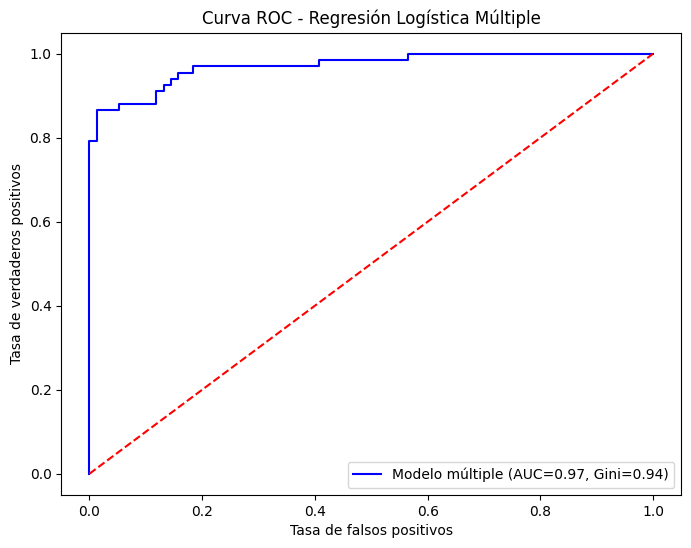



 Gini del modelo múltiple: 0.9419

 Ganancia/Pérdida de Gini respecto a radius: +0.03

 Ganancia/Pérdida de Gini respecto a texture: +0.38

 Ganancia/Pérdida de Gini respecto a concavity: +0.04


In [47]:
# Creando el modelo de Regresión Logística múltiple con las 3 variables radius, texture y concavity.

# Asignando las variables predictoras.
X = df_deteccion_cancer[['radius', 'texture', 'concavity']]
# Asignando la variable objetivo.
Y = df_deteccion_cancer['Diagnosis']

# Data split train/test 75/25 con semilla 135
X_train, X_test, Y_train, Y_test = train_test_split(
                                                    X,
                                                    Y,
                                                    test_size=0.25,
                                                    random_state=135
                                                    )

# Modelo de regresión logística múltiple
modelo_logisitco_multiple = LogisticRegression()
modelo_logisitco_multiple.fit(X_train, Y_train)

# Predicciones del modelo Regresión Logística múltiple.
Y_pred_prob_multiple = modelo_logisitco_multiple.predict_proba(X_test)[:, 1]

# Calcular AUC y Gini para Regresión Logística múltiple.
auc_multiple  = roc_auc_score(Y_test, Y_pred_prob_multiple)
gini_multiple = 2 * auc_multiple - 1

# Dibujando curva ROC
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob_multiple)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue',
         label=f'Modelo múltiple (AUC={auc_multiple:.2f}, Gini={gini_multiple:.2f})')
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.title('Curva ROC - Regresión Logística Múltiple')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend()
plt.show()

# Para realizar la evaluación Ganancia/Perdida, utilizaremos el diccionario de resultados
# previamente creado en el apartado anterior: resultados_rl_simple
print("\n\n Gini del modelo múltiple:", round(gini_multiple, 4))
for var, gini in resultados_rl_simple.items():
    diff = gini_multiple - gini['Gini']
    print(f"\n Ganancia/Pérdida de Gini respecto a {var}: {diff:+.2f}")

***Apartado 2.4***

**Si tuvieras que valorar definir un umbral para el modelo desarrollado. En que metrica te basarias?**

Siendo un tema de predicción médica, donde se debe realizar un diagnóstico bastante certero, considero que el modelo debe minimizar los falsos negativos, ya que, de no hacerlo, estos serían casos positivos que se podrían clasificar como negativos y tener graves repercusiones. Por lo tanto, siendo que el Gini nos da un mejor valor de predicción cuando se predice con el Radius, la métrica seria justamente utilizar la Regresión Logística Múltiple, tomando muy en cuenta los valores de Radius como métrica principal de predicción.

## Random Forest

***Apartado 3.1***

In [48]:
# Creando modelo de Árbol de clasificación.

# Asignando variables predictoras.
X = df_deteccion_cancer[['radius', 'texture', 'concavity']]

# Asignando variable objetivo.
Y = df_deteccion_cancer['Diagnosis']

# Data split train/test 80/20 con semilla 135
X_train, X_test, Y_train, Y_test = train_test_split(
                                                    X,
                                                    Y,
                                                    test_size=0.20,
                                                    random_state=135
                                                    )

# Generar modelo de árbol de clasificación.
modelo_arbol_clasificacion = DecisionTreeClassifier(
                                                    max_depth=7,
                                                    min_samples_split=10,
                                                    random_state=135
                                                    )

# Entrenar modelo de árbol de clasificación.
modelo_arbol_clasificacion.fit(X_train, Y_train)

# Generar predicción.
Y_pred = modelo_arbol_clasificacion.predict(X_test)

# Cálculo de métricas.
precision_tree = precision_score(Y_test, Y_pred)
recall_tree = recall_score(Y_test, Y_pred)
f1_tree = f1_score(Y_test, Y_pred)

print("Precisión:", round(precision_tree, 4))
print("Recall:", round(recall_tree, 4))
print("F1-Score:", round(f1_tree, 4))

Precisión: 0.9412
Recall: 0.8727
F1-Score: 0.9057


***Apartado 3.2***

Random Forest - Precisión: 0.9608
Random Forest - Recall: 0.8909
Random Forest - F1-Score: 0.9245
Random Forest - AUC: 0.9877


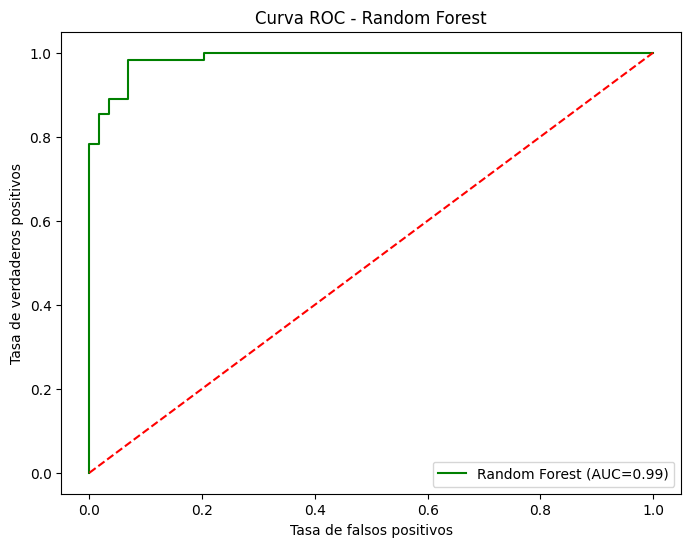

In [49]:
# Creando Random Forest con 100 estimadores.

# Asignando variables predictoras.
X = df_deteccion_cancer[['radius', 'texture', 'concavity']]

# Asignando variable objetivo.
Y = df_deteccion_cancer['Diagnosis']

# Data split train 80, test 20 con semilla 135.
X_train, X_test, y_train, y_test = train_test_split(
                                                    X,
                                                    Y,
                                                    test_size=0.20,
                                                    random_state=135
                                                    )


# Crear modelo Random Forest.
modelo_random_forest = RandomForestClassifier(
                                              n_estimators=100,
                                              max_depth=6,
                                              random_state=135
                                              )

# Entrenar modelo Random Forest.
modelo_random_forest.fit(X_train, y_train)

# Generar predicciones.

# y_prediccion_random_forest se utilizará para calcular precision_rf, recall_rf y f1_rf
# Vector de predicciones finales, donde cada elemento puede ser benigno o maligno.
y_prediccion_random_forest = modelo_random_forest.predict(X_test)

# y_prediccion_probabilidad_random_forest se utilizará para calcular auc_rf
# Vector de probabilidades estimadas para la clase positiva (Diagnosis = 1).
y_prediccion_probabilidad_random_forest = modelo_random_forest.predict_proba(X_test)[:, 1]

# Generar Métricas.
# Métricas dependientes de y_prediccion_random_forest.
precision_random_forest = precision_score(y_test, y_prediccion_random_forest)
recall_random_forest = recall_score(y_test, y_prediccion_random_forest)
f1_random_forest = f1_score(y_test, y_prediccion_random_forest)
# Métricas dependientes de y_prediccion_probabilidad_random_forest.
auc_random_forest = roc_auc_score(y_test, y_prediccion_probabilidad_random_forest)

# Imprimiendo Métricas.
print("Random Forest - Precisión:", round(precision_random_forest, 4))
print("Random Forest - Recall:", round(recall_random_forest, 4))
print("Random Forest - F1-Score:", round(f1_random_forest, 4))
print("Random Forest - AUC:", round(auc_random_forest, 4))

# Dibujar curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prediccion_probabilidad_random_forest)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='green', label=f'Random Forest (AUC={auc_rf:.2f})')
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Random Forest')
plt.legend()


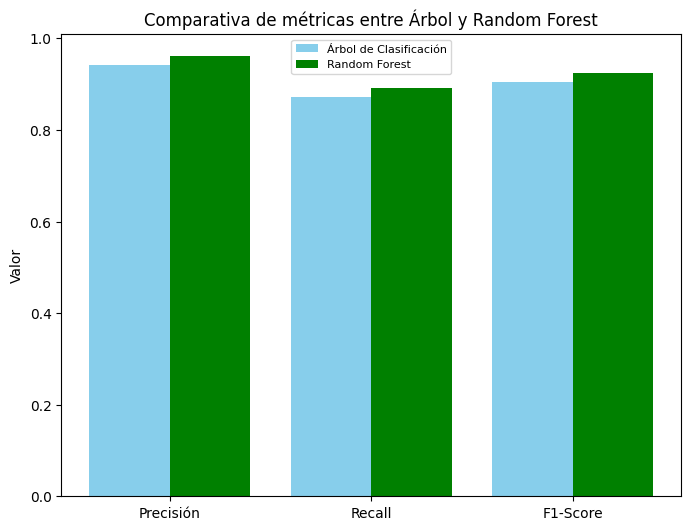



 Árbol de Clasificación -> 
 Precisión: 0.9412 
 Recall: 0.8727 
 F1: 0.9057


 Random Forest -> 
 Precisión: 0.9608 
 Recall: 0.8909 
 F1: 0.9245


In [50]:
# Creando gráfico comparativo entre árbol de decisión y random forest.

# Crear arreglo de labels.
labels = ['Precisión', 'Recall', 'F1-Score']
# Crear arreglo de métricas de árbol de decisión.
tree_scores = [precision_tree, recall_tree, f1_tree]
# Crear arreglo de métricas de random forest.
random_forest_scores = [precision_random_forest, recall_random_forest, f1_random_forest]

# Crear gráfico comparativo.
x = range(len(labels))
plt.figure(figsize=(8,6))
plt.bar([i-0.2 for i in x], tree_scores, width=0.4, label='Árbol de Clasificación', color='skyblue')
plt.bar([i+0.2 for i in x], random_forest_scores, width=0.4, label='Random Forest', color='green')
plt.xticks(x, labels)
plt.ylabel('Valor')
plt.title('Comparativa de métricas entre Árbol y Random Forest')
plt.legend(fontsize=8)
plt.show()

# Mostrar valores en consola
print("\n\n Árbol de Clasificación -> \n Precisión:", round(precision_tree,4),
      "\n Recall:", round(recall_tree,4),
      "\n F1:", round(f1_tree,4))
print("\n\n Random Forest -> \n Precisión:", round(precision_random_forest,4),
      "\n Recall:", round(recall_random_forest,4),
      "\n F1:", round(f1_random_forest,4))

#1
**¿Qué modelo predice mejor de todos los desarrollados en los dos
últimos apartados?**

***Random Forest debido a que en el comparativo, tiene mejores resultados.***

#2
**¿Cuál crees que pueden ser las causas de que dicho modelo tenga un mejor
rendimiento?**

***Se debe considerar que Random Forest es un grupo de Árboles de decisión, los cuales, en su conjunto fortalecen la capacidad de predicción del modelo Random Forest. Dicho modelo, al ser mas robusto, suele manejar mejor las pequeñas variaciones en los datos y a la vez aprovecha la diversidad de árboles de decisión para trabajar con relaciones más complejas de datos.***